In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

<h4 style="color:purple">Load the dataset</h4>

In [ ]:
(X_train, y_train), (X_test,y_test) = datasets.cifar10.load_data()
X_train.shape

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


(50000, 32, 32, 3)

In [ ]:
X_test.shape

(10000, 32, 32, 3)

Here we see there are 50000 training images and 1000 test images

In [ ]:
y_train.shape

(50000, 1)

In [ ]:
y_train[:5]

y_train is a 2D array, for our classification having 1D array is good enough. so we will convert this to now 1D array

In [ ]:
y_train = y_train.reshape(-1,)
y_train[:5]

array([6, 9, 9, 4, 1], dtype=uint8)

In [ ]:
y_test = y_test.reshape(-1,)
y_test.shape

(10000,)

In [ ]:
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

Let's plot some images to see what they are

In [ ]:
def plot_sample(X, y, index):
    plt.figure(figsize = (15,2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

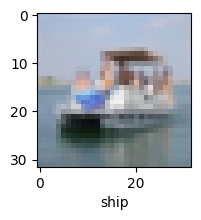

In [ ]:
plot_sample(X_train, y_train, 49000)

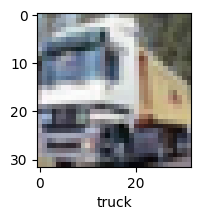

In [ ]:
plot_sample(X_train, y_train, 1)

Normalize the images to a number from 0 to 1. Image has 3 channels (R,G,B) and each value in the channel can range from 0 to 255. Hence to normalize in 0-->1 range, we need to divide it by 255

<h4 style="color:purple">Normalizing the training data</h4>

In [ ]:
X_train = X_train / 255.0
X_test = X_test / 255.0

<h4 style="color:purple">Build simple artificial neural network for image classification</h4>

In [ ]:
ann = models.Sequential([
        layers.Flatten(input_shape=(32,32,3)),
        layers.Dense(3000, activation='relu'),
        layers.Dense(1000, activation='relu'),
        layers.Dense(10, activation='softmax')
    ])

ann.compile(optimizer='SGD',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

ann.fit(X_train, y_train, epochs=5)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/reshaping/flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 4ms/step - accuracy: 0.3038 - loss: 1.9287
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4207 - loss: 1.6439
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4528 - loss: 1.5560
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4742 - loss: 1.4889
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.4905 - loss: 1.4379


**You can see that at the end of 5 epochs, accuracy is at around 49%**

In [ ]:
from sklearn.metrics import confusion_matrix , classification_report
import numpy as np
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]

print("Classification Report: \n", classification_report(y_test, y_pred_classes))

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.60      0.50      0.54      1000
           1       0.67      0.53      0.59      1000
           2       0.37      0.39      0.38      1000
           3       0.42      0.22      0.29      1000
           4       0.52      0.23      0.32      1000
           5       0.43      0.28      0.34      1000
           6       0.56      0.45      0.50      1000
           7       0.29      0.84      0.43      1000
           8       0.67      0.57      0.62      1000
           9       0.54      0.60      0.57      1000

    accuracy                           0.46     10000
   macro avg       0.51      0.46      0.46     10000
weighted avg       0.51      0.46      0.46     10000



<h4 style="color:purple">Now let us build a convolutional neural network to train our images</h4>

In [ ]:
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),

    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
cnn.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
cnn.fit(X_train, y_train, epochs=10)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.3981 - loss: 1.6657
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6037 - loss: 1.1269
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6618 - loss: 0.9735
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6961 - loss: 0.8758
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7187 - loss: 0.8152
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7442 - loss: 0.7433
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7574 - loss: 0.6986
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7758 - loss: 0.6437
Epoch 9/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.7916 - loss: 0.5967
Epoch 10/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8062 - loss: 0.5508


**With CNN, at the end 5 epochs, accuracy was at around 70% which is a significant improvement over ANN. CNN's are best for image classification and gives superb accuracy. Also computation is much less compared to simple ANN as maxpooling reduces the image dimensions while still preserving the features**

In [ ]:
cnn.evaluate(X_test,y_test)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.7108 - loss: 0.9148


[0.9280142784118652, 0.7049999833106995]

In [ ]:
y_pred = cnn.predict(X_test)
y_pred[:5]

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


array([[4.54363134e-03, 1.19946371e-05, 6.20653191e-06, 9.69331205e-01,
        1.97699301e-05, 1.15264393e-02, 8.98153448e-05, 4.66752390e-05,
        1.42040569e-02, 2.20225935e-04],
       [1.20961704e-04, 1.06631014e-04, 6.43851816e-09, 9.85674387e-09,
        9.08061733e-12, 1.26939639e-10, 4.58449140e-10, 1.44125961e-10,
        9.99746501e-01, 2.58097280e-05],
       [5.67627288e-02, 9.52123292e-03, 4.28091153e-04, 2.10071285e-03,
        2.76212359e-05, 6.36769328e-05, 5.03866060e-04, 4.70399573e-05,
        9.04008746e-01, 2.65362095e-02],
       [4.45845574e-01, 1.32332081e-02, 2.93157343e-03, 3.07776104e-03,
        5.17308363e-04, 1.40046526e-04, 2.11668128e-04, 1.46144766e-05,
        5.33031881e-01, 9.96380346e-04],
       [2.59819831e-06, 1.37765403e-03, 5.56196347e-02, 1.81336515e-02,
        6.53392911e-01, 1.44918344e-03, 2.69912481e-01, 2.16161334e-05,
        7.42254706e-05, 1.60686814e-05]], dtype=float32)

In [ ]:
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]

[3, 8, 8, 0, 6]

In [ ]:
y_test[:5]

array([3, 8, 8, 0, 6], dtype=uint8)

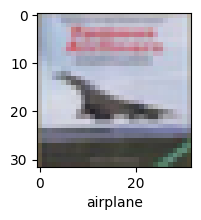

In [ ]:
plot_sample(X_test, y_test,3)

In [ ]:
classes[y_classes[3]]

NameError: name 'y_classes' is not defined

In [ ]:
classes[y_classes[2]]

'ship'

170498071/170498071 [==============================] - 2s 0us/step
Epoch 1/5
1563/1563 [==============================] - 88s 56ms/step - loss: 1.8113 - accuracy: 0.3537
Epoch 2/5
1563/1563 [==============================] - 86s 55ms/step - loss: 1.6219 - accuracy: 0.4252
Epoch 3/5
1563/1563 [==============================] - 89s 57ms/step - loss: 1.5419 - accuracy: 0.4560
Epoch 4/5
1563/1563 [==============================] - 84s 54ms/step - loss: 1.4827 - accuracy: 0.4788
Epoch 5/5
313/313 [==============================] - 5s 16ms/step
Classification Report: 
               precision    recall  f1-score   support

           0       0.57      0.55      0.56      1000
           1       0.66      0.51      0.57      1000
           2       0.42      0.20      0.27      1000
           3       0.41      0.27      0.32      1000
           4       0.33      0.57      0.42      1000
           5       0.51      0.24      0.32      1000
           6       0.47      0.62      0.53      10

'ship'

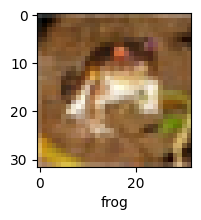

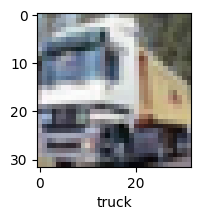

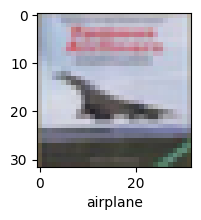

In [ ]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Load the dataset
(X_train, y_train), (X_test, y_test) = datasets.cifar10.load_data()
X_train.shape
X_test.shape

# Reshape y_train and y_test to 1D arrays
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)

# Define the class names
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

# Function to plot sample images
def plot_sample(X, y, index):
    plt.figure(figsize=(15, 2))
    plt.imshow(X[index])
    plt.xlabel(classes[y[index]])

# Plot sample images from the training set
plot_sample(X_train, y_train, 0)
plot_sample(X_train, y_train, 1)

# Normalize the images to values between 0 and 1
X_train = X_train / 255.0
X_test = X_test / 255.0

# Build a simple artificial neural network for image classification
ann = models.Sequential([
    layers.Flatten(input_shape=(32, 32, 3)),
    layers.Dense(3000, activation='relu'),
    layers.Dense(1000, activation='relu'),
    layers.Dense(10, activation='softmax')
])

ann.compile(optimizer='SGD', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
ann.fit(X_train, y_train, epochs=5)

# Evaluate the ANN model
from sklearn.metrics import confusion_matrix, classification_report
y_pred = ann.predict(X_test)
y_pred_classes = [np.argmax(element) for element in y_pred]
print("Classification Report: \n", classification_report(y_test, y_pred_classes))

# Build a convolutional neural network to train the images
cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),

    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(X_train, y_train, epochs=10, batch_size=64)

# Evaluate the CNN model
cnn.evaluate(X_test, y_test)

y_pred = cnn.predict(X_test)
y_classes = [np.argmax(element) for element in y_pred]
y_classes[:5]
y_test[:5]
plot_sample(X_test, y_test, 3)
classes[y_classes[3]]
classes[y_classes[2]]
model.save('model.h5')

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)
classes = ["airplane","automobile","bird","cat","deer","dog","frog","horse","ship","truck"]

X_train = X_train / 255.0
X_test = X_test / 255.0

datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)


cnn = models.Sequential([
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(filters=32, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(filters=64, kernel_size=(3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])


cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])


history = cnn.fit(datagen.flow(X_train, y_train, batch_size=128), epochs=30,
                  validation_data=(X_test, y_test))


cnn.evaluate(X_test, y_test)


170498071/170498071 [==============================] - 13s 0us/step
Epoch 1/30
391/391 [==============================] - 46s 85ms/step - loss: 1.7240 - accuracy: 0.3912 - val_loss: 2.3701 - val_accuracy: 0.2799
Epoch 2/30
391/391 [==============================] - 34s 88ms/step - loss: 1.3402 - accuracy: 0.5160 - val_loss: 1.2636 - val_accuracy: 0.5709
Epoch 3/30
391/391 [==============================] - 31s 80ms/step - loss: 1.1994 - accuracy: 0.5753 - val_loss: 1.2180 - val_accuracy: 0.5845
Epoch 4/30
391/391 [==============================] - 33s 85ms/step - loss: 1.0983 - accuracy: 0.6107 - val_loss: 1.3148 - val_accuracy: 0.5761
Epoch 5/30
391/391 [==============================] - 31s 79ms/step - loss: 1.0330 - accuracy: 0.6363 - val_loss: 1.0467 - val_accuracy: 0.6494
Epoch 6/30
391/391 [==============================] - 34s 87ms/step - loss: 0.9790 - accuracy: 0.6544 - val_loss: 0.8992 - val_accuracy: 0.6925
Epoch 7/30
391/391 [==============================] - 32s 81ms/step 

[0.533119797706604, 0.8148999810218811]

In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
from google.colab import files

# Load CIFAR-10 and prepare
(X_train, y_train), (X_test, y_test) = tf.keras.datasets.cifar10.load_data()
y_train = y_train.reshape(-1,)
y_test = y_test.reshape(-1,)
classes = ["airplane", "automobile", "bird", "cat", "deer",
           "dog", "frog", "horse", "ship", "truck"]

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Data Augmentation
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(X_train)

# CNN Model
cnn = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)),
    layers.BatchNormalization(),
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2, 2)),
    layers.Dropout(0.25),

    layers.Flatten(),
    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),
    layers.Dense(10, activation='softmax')
])

# Compile and train
cnn.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])
cnn.fit(datagen.flow(X_train, y_train, batch_size=128),
        epochs=10,
        validation_data=(X_test, y_test))

# Upload image
print("📤 Upload a test image (JPG or PNG)...")
uploaded = files.upload()

for file_name in uploaded.keys():
    img = Image.open(file_name).resize((32, 32))  # Resize to match CIFAR-10
    img_array = np.array(img)

    if img_array.shape != (32, 32, 3):
        print(" Uploaded image must be RGB and 32x32 after resizing.")
        continue

    img_array = img_array / 255.0  # Normalize
    img_array = np.expand_dims(img_array, axis=0)  # (1, 32, 32, 3)

    prediction = cnn.predict(img_array)
    predicted_class = classes[np.argmax(prediction[0])]

    # Show image and prediction
    plt.imshow(img)
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 4s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/convolutional/base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


391/391 ━━━━━━━━━━━━━━━━━━━━ 43s 86ms/step - accuracy: 0.3242 - loss: 2.0841 - val_accuracy: 0.2445 - val_loss: 2.5590
Epoch 2/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 73ms/step - accuracy: 0.4834 - loss: 1.4245 - val_accuracy: 0.5941 - val_loss: 1.1220
Epoch 3/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 29s 74ms/step - accuracy: 0.5569 - loss: 1.2389 - val_accuracy: 0.6465 - val_loss: 1.0175
Epoch 4/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 72ms/step - accuracy: 0.5981 - loss: 1.1324 - val_accuracy: 0.6494 - val_loss: 1.0234
Epoch 5/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 68ms/step - accuracy: 0.6297 - loss: 1.0516 - val_accuracy: 0.6632 - val_loss: 0.9681
Epoch 6/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 41s 69ms/step - accuracy: 0.6479 - loss: 1.0046 - val_accuracy: 0.7006 - val_loss: 0.8707
Epoch 7/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 27s 69ms/step - accuracy: 0.6705 - loss: 0.9418 - val_accuracy: 0.6906 - val_loss: 0.9310
Epoch 8/10
391/391 ━━━━━━━━━━━━━━━━━━━━ 28s 71ms/step - accuracy: 0.6842 - loss: 0.9058 - val_accurac